# Sensitivity Analysis — Factor & Loading Coherence

- **Section 1**: `coef_reg` ∈ {0.9, 1.0, 1.1, **1.2**, 1.3, 1.4} (default = 1.2)
- **Section 2**: `coef_fe` ∈ {0.01, 0.05, **0.1**, 0.2, 0.5} (default = 0.1)

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 6.5,
    'ytick.labelsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'savefig.dpi': 300,
    'figure.dpi': 150,
})

SAVE_DIR = '/import/home2/share/yqzeng/MacSGP/revision/vis/1.3minor'

def coherence_df(param_list, adata_list, default_adata, param_name):
    """Compute per-celltype Pearson coherence of factor and loading vs default."""
    L_ref = default_adata.varm['loading']
    F_ref = default_adata.obsm['factor']
    L_ref = L_ref.values if hasattr(L_ref, 'values') else L_ref
    F_ref = F_ref.values if hasattr(F_ref, 'values') else F_ref
    celltypes = list(default_adata.varm['loading'].columns) if hasattr(default_adata.varm['loading'], 'columns') \
                else [f'CT_{i}' for i in range(L_ref.shape[1])]
    records = []
    for val, adata in zip(param_list, adata_list):
        L = adata.varm['loading']
        F = adata.obsm['factor']
        L = L.values if hasattr(L, 'values') else L
        F = F.values if hasattr(F, 'values') else F
        for ct_idx, ct_name in enumerate(celltypes):
            lc = np.abs(pearsonr(L[:, ct_idx], L_ref[:, ct_idx])[0])
            fc = np.abs(pearsonr(F[:, ct_idx], F_ref[:, ct_idx])[0])
            records.append({param_name: val, 'celltype': ct_name,
                            'Loading Coherence': lc, 'Factor Coherence': fc})
    return pd.DataFrame(records), celltypes

def plot_coherence(df, param_name, celltypes, default_val, xlabel, xscale='linear', tag=''):
    n_ct = len(celltypes)
    cmap = plt.cm.get_cmap('tab10', n_ct)
    fig, axes = plt.subplots(1, 2, figsize=(15 / 2.54, 6 / 2.54))
    for ax, metric in zip(axes, ['Factor Coherence', 'Loading Coherence']):
        for ct_idx, ct_name in enumerate(celltypes):
            sub = df[df['celltype'] == ct_name]
            ax.plot(sub[param_name], sub[metric], 'o-', color=cmap(ct_idx),
                    label=ct_name, markersize=3, linewidth=1)
        ax.axvline(x=default_val, color='grey', linestyle='--', alpha=0.6, linewidth=0.8)
        ax.text(default_val, 1.02, 'default', ha='center', va='bottom', fontsize=10, color='grey',
                transform=ax.get_xaxis_transform())
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel('Factor score coherence' if metric == 'Factor Coherence' else 'Gene loading coherence', fontsize=10)
        ax.set_ylim([-0.05, 1.05])
        ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_xscale(xscale)
        ax.set_xticks(df[param_name].unique())
        #ax.set_title(metric)
        ax.grid(True, alpha=0.3, linewidth=0.4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.15, 0.55), fontsize=6, frameon=False)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'sensitivity_{tag}_coherence.pdf'), bbox_inches='tight')
    plt.show()

In [2]:
# coef_reg
RESULT_REG = '/import/home2/share/yqzeng/MacSGP/results/kidney_cancer'
coef_reg_list = [0.9, 1.0, 1.1, 1.2, 1.3, 1.4]
adata_reg_list = [ad.read_h5ad(os.path.join(RESULT_REG, f'result_coef_reg_{v:.1f}.h5ad')) for v in coef_reg_list]
adata_reg_default = adata_reg_list[coef_reg_list.index(1.2)]

# coef_fe
RESULT_FE = '/import/home2/share/yqzeng/MacSGP/results/kidney_cancer'
coef_fe_list = [0.01, 0.05, 0.1, 0.15, 0.2]
adata_fe_list = [ad.read_h5ad(os.path.join(RESULT_FE, f'result_coef_ae_{v:.1f}.h5ad')) for v in coef_fe_list]
adata_fe_default = adata_fe_list[coef_fe_list.index(0.1)]

## Section 1: `coef_reg` Sensitivity

In [ ]:
ct_plot = ['B-cell',
 'EC',
 'Epi_PT',
 'Epi_non-PT',
 'Fibro',
 'Myeloid',
 'Plasma',
 'RCC',
 'T-cell',
 ]

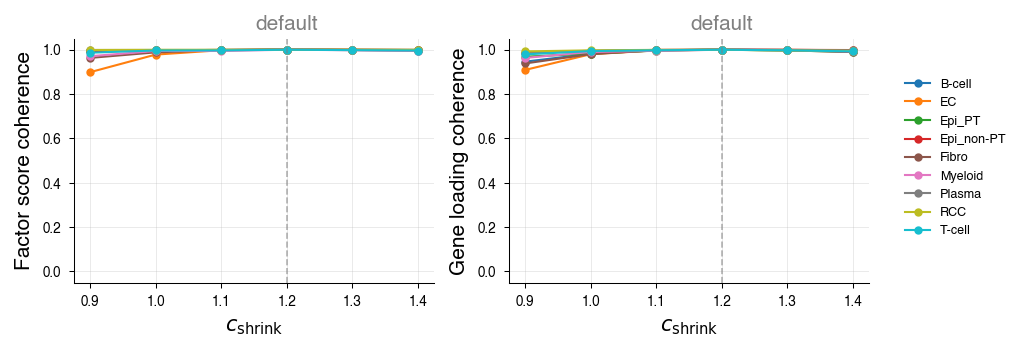

In [4]:
df_reg, celltypes_reg = coherence_df(coef_reg_list, adata_reg_list, adata_reg_default, 'coef_reg')
plot_coherence(df_reg, 'coef_reg', ct_plot, default_val=1.2,
               xlabel='$c_{\\mathrm{shrink}}$', xscale='linear', tag='coef_reg')

## Section 2: `coef_fe` Sensitivity

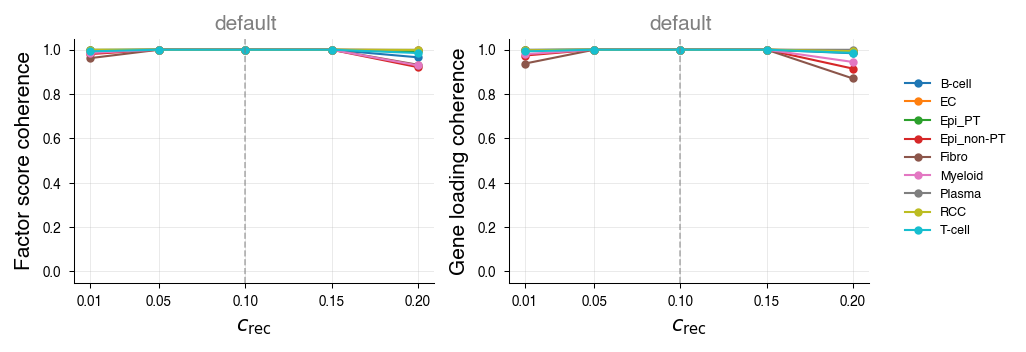

In [81]:
df_fe, celltypes_fe = coherence_df(coef_fe_list, adata_fe_list, adata_fe_default, 'coef_fe')
plot_coherence(df_fe, 'coef_fe', ct_plot, default_val=0.1,
               xlabel='$c_{\\mathrm{rec}}$', #xscale='log', 
               tag='coef_fe')